In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
d

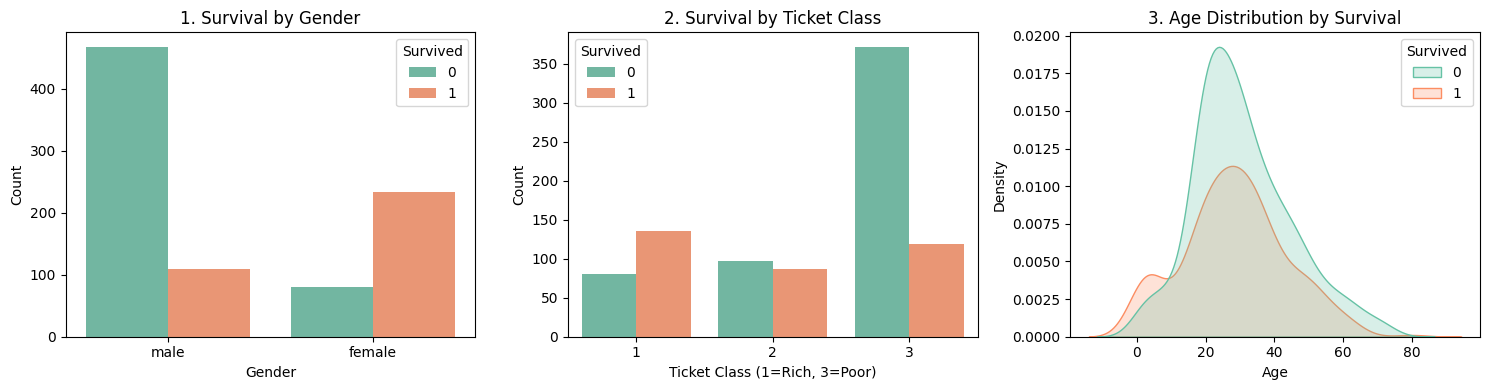

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('1. Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')
plt.title('2. Survival by Ticket Class')
plt.xlabel('Ticket Class (1=Rich, 3=Poor)')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, palette='Set2')
plt.title('3. Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [4]:
data = df.copy()
data.drop(['Name', 'PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True, dtype=int)

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


In [5]:
from sklearn.model_selection import train_test_split
x = data.drop('Survived', axis=1)
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(X_train.shape[0])
print(X_test.shape[0])

712
179


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:      ", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:      ", accuracy_score(y_test, rf_pred))


Logistic Regression Accuracy: 0.8100558659217877
Decision Tree Accuracy:       0.7877094972067039
Random Forest Accuracy:       0.8100558659217877


 Classification Report (Logistic Regression) 
              precision    recall  f1-score   support

    Died (0)       0.83      0.86      0.84       105
Survived (1)       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


 Feature Weights 
Sex          -2.590612
Pclass       -0.938550
Embarked_S   -0.401270
SibSp        -0.294975
Embarked_Q   -0.112181
Parch        -0.108025
Age          -0.030592
Fare          0.002570
dtype: float64


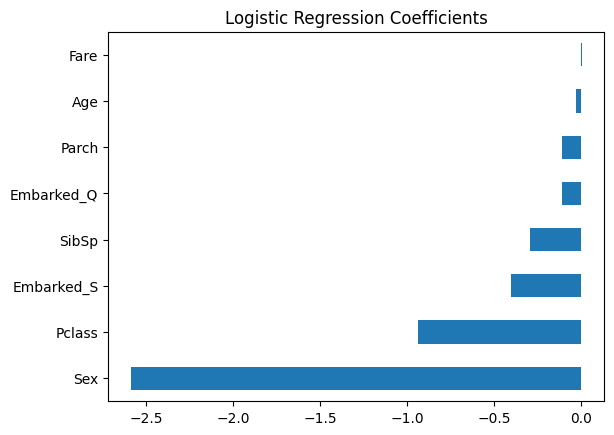

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

print(" Classification Report (Logistic Regression) ")
print(classification_report(y_test, log_pred, target_names=['Died (0)', 'Survived (1)']))

weights = pd.Series(log_reg.coef_[0], index=X_train.columns)
print("\n Feature Weights ")
print(weights.sort_values())

weights.sort_values().plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.show()


 Classification Report (Random Forest) 
              precision    recall  f1-score   support

    Died (0)       0.83      0.86      0.84       105
Survived (1)       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


 Feature Importances 
Fare          0.279199
Sex           0.266967
Age           0.249413
Pclass        0.081051
SibSp         0.053500
Parch         0.035840
Embarked_S    0.024301
Embarked_Q    0.009729
dtype: float64


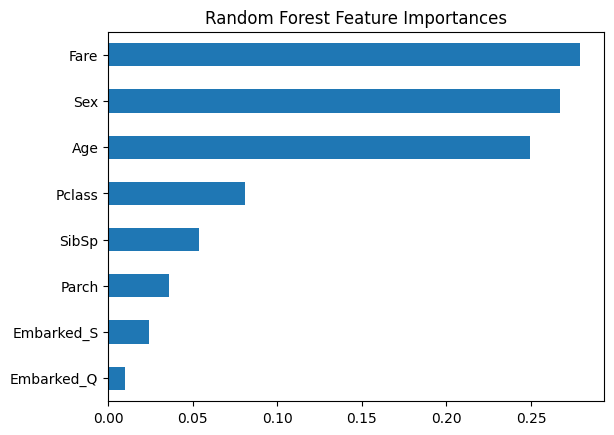

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

print(" Classification Report (Random Forest) ")
print(classification_report(y_test, rf_pred, target_names=['Died (0)', 'Survived (1)']))

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print("\n Feature Importances ")
print(importances.sort_values(ascending=False))

importances.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importances')
plt.show()


In [9]:
import pandas as pd

test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
passenger_ids = test_df['PassengerId']

test_features = test_df.drop(columns=['Name', 'PassengerId', 'Ticket', 'Cabin'])

test_features['Age'] = test_features['Age'].fillna(test_features['Age'].median())
test_features['Fare'] = test_features['Fare'].fillna(test_features['Fare'].median())
test_features['Embarked'] = test_features['Embarked'].fillna('S')

test_features['Sex'] = test_features['Sex'].map({'female': 0, 'male': 1})
test_features = pd.get_dummies(test_features, columns=['Embarked'], drop_first=True)

test_features = test_features.reindex(columns=X_train.columns, fill_value=0)

final_predictions = rf_model.predict(test_features)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': final_predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))


   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
